# **Predicción del riesgo de estrés financiero en asalariados de la Comunidad de Madrid**
## **TFM - Máster de Data Science & IA**
### *Pipeline de datos: Silver → Gold*
---

**Fuente de datos:** Encuesta de Condiciones de Vida (ECV) 2025, INE  
**Población objetivo:** Asalariados en activo residentes en la Comunidad de Madrid  
**Resultado de esta capa:** `dataset_analitico.csv` — dataset limpio listo para modelado

---

### *Estructura del notebook*

Este notebook documenta y justifica cada decisión del pipeline de preparación de datos siguiendo la **arquitectura medallón**:

| Capa | Contenido |
|------|-----------|
| 🥉 **Bronze** | Exploración de los datos en crudo tal como los publica el INE |
| 🥈 **Silver** | Limpieza, joins, filtros, imputación, renombrado y decodificación |
| 🥇 **Gold**   | Construcción del target `estres_financiero_alto`, feature engineering y encoding para modelado |  


> **Nota metodológica:** Este notebook reproduce la lógica del script `limpieza_ecv.py` de forma narrativa y exploratoria. El código de producción queda en el script; aquí el objetivo es documentar y visualizar cada decisión para la memoria del TFM.

---

## 0. **Configuración del entorno**

Librerías estándar de análisis de datos. No se requieren dependencias adicionales.

In [28]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from pathlib import Path

from scripts.constants_var import *
from utils.cleaning_utils import cargar_csv
from utils.visualizations_utils import urban_grade_CCMM, PL032_vs_PL040A, nuls_space_dis, diagram_relationship

# Estilo visual 
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'sans-serif',
})


## 1. **CAPA SILVER - Limpieza y preparación**

La capa Silver transforma los datos en bruto en un dataset analítico limpio y documentado. Cada paso está justificado y acompañado de exploración visual cuando ayuda a entender la decisión.

### S.1 **Joins entre ficheros**


In [29]:
#  Carga de los 4 ficheros originales

df_d = cargar_csv('01_datos_hogar.csv')       # D: datos básicos hogar
df_h = cargar_csv('02_detalles_hogar.csv')    # H: detalle hogar
df_p = cargar_csv('03_detalles_adulto.csv')   # P: datos adulto
df_r = cargar_csv('04_datos_persona.csv')     # R: datos persona

# Join D + H (nivel hogar)
df_hogar = df_d.merge(df_h, left_on='DB030', right_on='HB030', how='inner')

# Join R + P (nivel persona)
df_persona = df_r.merge(df_p, left_on='RB030', right_on='PB030', how='inner')

# Clave hogar derivada desde ID persona
df_persona['id_hogar_join'] = df_persona['RB030'].astype(int) // 100

# Join hogar + persona
df = df_hogar.merge(df_persona, left_on='DB030', right_on='id_hogar_join', how='inner')

print(f"Fichero D:           {df_d.shape[0]:>7,} hogares  × {df_d.shape[1]:>3} variables")
print(f"Fichero H:           {df_h.shape[0]:>7,} hogares  × {df_h.shape[1]:>3} variables")
print(f"Fichero R:           {df_r.shape[0]:>7,} personas × {df_r.shape[1]:>3} variables")
print(f"Fichero P:           {df_p.shape[0]:>7,} personas × {df_p.shape[1]:>3} variables")
print(f"─" * 50)
print(f"Tras join D+H:       {df_hogar.shape[0]:>7,} filas × {df_hogar.shape[1]:>3} columnas")
print(f"Tras join R+P:       {df_persona.shape[0]:>7,} filas × {df_persona.shape[1]:>3} columnas")
print(f"Tras join completo:  {df.shape[0]:>7,} filas × {df.shape[1]:>3} columnas")


Fichero D:            29,369 hogares  ×   9 variables
Fichero H:            29,369 hogares  × 156 variables
Fichero R:            71,398 personas ×  46 variables
Fichero P:            60,825 personas × 245 variables
──────────────────────────────────────────────────
Tras join D+H:        29,369 filas × 165 columnas
Tras join R+P:        60,825 filas × 292 columnas
Tras join completo:   60,825 filas × 457 columnas


**Decisión de diseño - join inner:** Se usa `inner join` en todos los casos porque la ECV garantiza cobertura completa para los hogares y personas de la muestra. El join inner elimina únicamente registros huérfanos (inexistentes en la práctica con microdatos del INE).

### S.2 **Filtro geográfico - Comunidad de Madrid**

El TFM se centra exclusivamente en la Comunidad de Madrid (`DB040 = 'ES30'`). El INE codifica la región a nivel NUTS-2.

> **Limitación metodológica:** El INE no publica la provincia ni el municipio en los microdatos públicos por razones de confidencialidad. El nivel de desagregación geográfica más fino disponible es `DB100` (grado de urbanización), que distingue tres zonas: muy poblada, media y poco poblada.


In [30]:
# Distribución regional antes del filtro
print('Distribución por comunidad autónoma (muestra completa):')
reg_counts = df['DB040'].value_counts().head(10)
print(reg_counts.to_string())
print(f'\nTotal CCAA: {df['DB040'].nunique()}')

# Filtro Madrid
df = df[df['DB040'].astype(str).str.strip() == 'ES30'].copy()
print(f'\nTras filtro Madrid (ES30): {len(df):,} personas')


Distribución por comunidad autónoma (muestra completa):
DB040
ES51    12398
ES61     6843
ES30     6035
ES52     4760
ES11     3362
ES41     3346
ES21     2833
ES62     2512
ES42     2497
ES24     2434

Total CCAA: 19

Tras filtro Madrid (ES30): 6,035 personas


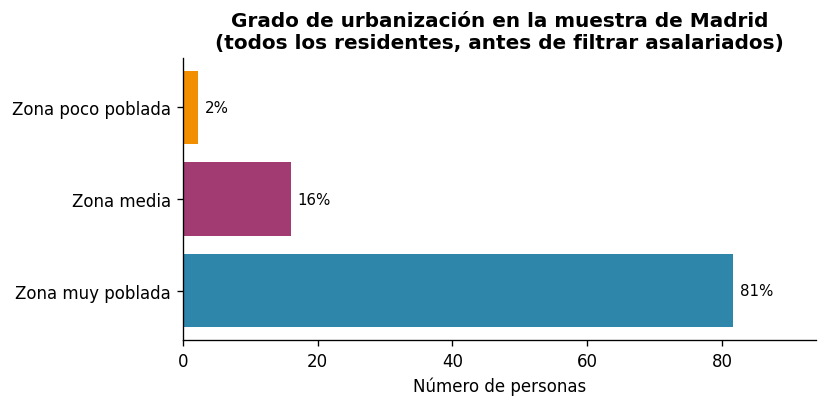

-> La Comunidad de Madrid es eminentemente urbana: el 81% reside en zonas muy pobladas.


In [31]:
# Visualización del grado de urbanización en Madrid (antes de filtrar asalariados)
urb_map = {'1': 'Zona muy poblada', '2': 'Zona media', '3': 'Zona poco poblada'}
urb = df['DB100'].astype(str).str.strip().map(urb_map).value_counts(normalize=True)*100

urban_grade_CCMM(urb)

### S.3 **Filtro de población objetivo - Asalariados en activo**

El estudio se centra en **asalariados que están trabajando en el momento de la encuesta**. Para identificarlos se necesitan dos condiciones simultáneas:

| Variable | Código | Significado |
|----------|--------|-------------|
| `PL032` | `1` | Persona trabajando (situación actividad autodefinida) |
| `PL040A` | `3` | Asalariado en empleo **actual** |

**¿Por qué `PL040A` y no `PL040B`?**  
`PL040B` recoge la situación profesional del **último empleo** y solo tiene valores para personas que ya no trabajan (inactivos o desempleados). Usarla filtraría una población completamente diferente a la de interés.


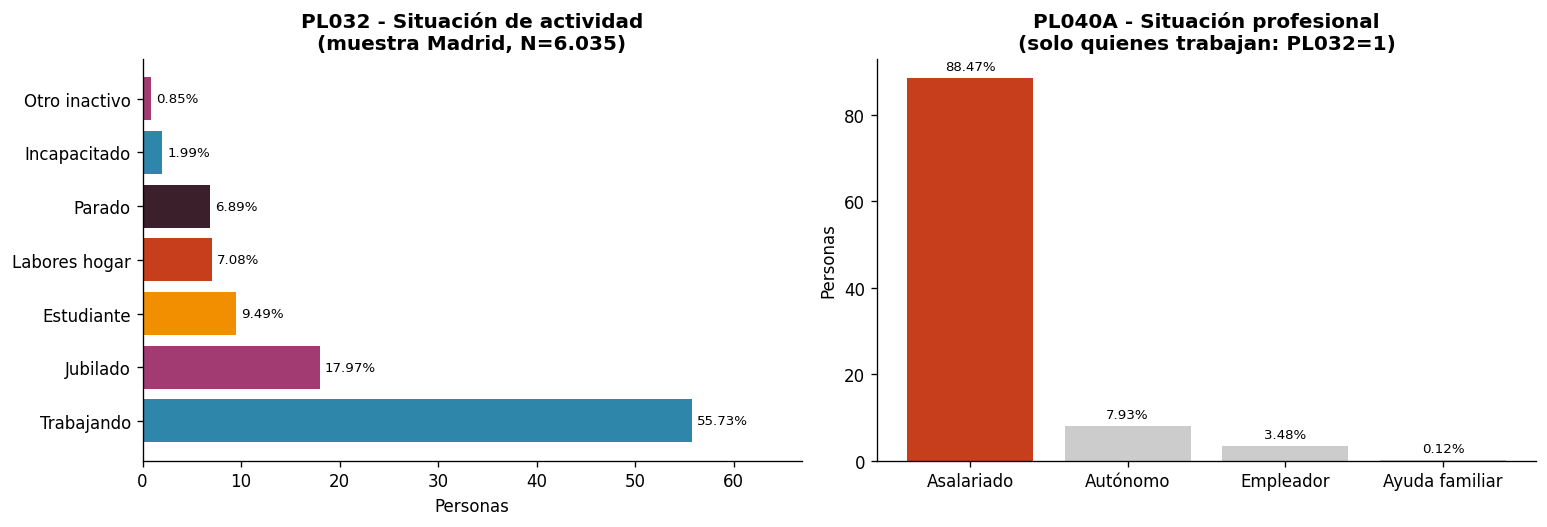

In [32]:
# Distribución de PL032 en Madrid (situación de actividad)
PL032_vs_PL040A(df)


In [33]:
n_antes = len(df)
df = df[
    (df['PL032'].astype(str).str.strip() == '1') &
    (df['PL040A'].astype(str).str.strip() == '3')
].copy()
n_despues = len(df)

print(f"Personas en Madrid (todos):                  {n_antes:>6,}")
print(f"Asalariados en activo (filtro aplicado):     {n_despues:>6,}")
print(f"Excluidos por filtro:                        {n_antes - n_despues:>6,}  ({(n_antes-n_despues)/n_antes*100:.1f}%)")
print(f"\nTamaño final de la muestra analítica: {n_despues:,} asalariados")


Personas en Madrid (todos):                   6,035
Asalariados en activo (filtro aplicado):      2,947
Excluidos por filtro:                         3,088  (51.2%)

Tamaño final de la muestra analítica: 2,947 asalariados


### S.4 **Selección de variables**

Tras una exhaustiva investigación de todas las variables en base a la documentación etraída de cada CSV, se seleccionan **64 variables** de las 457 disponibles tras los joins. El criterio de selección prioriza:

1. **Valor predictivo** para el estrés financiero (rentas, empleo, cargas)
2. **No redundancia** (se excluyen rentas brutas cuando existe la neta)
3. **No granularidad excesiva** (se excluyen `PL211*` — meses por situación mes a mes — con alta correlación interna)
4. **Flags `_F`** se incluyen temporalmente para imputar nulos y se eliminan tras usarlos

A continuación se muestra el inventario por grupos:


In [34]:
df['HB100_F'].value_counts()

HB100_F
 1    2860
-1      87
Name: count, dtype: int64

In [35]:
# Lista de variables seleccionadas (misma que en limpieza_ecv.py)
vars_seleccionadas = [
    # Identificadores
    'DB030', 'RB030', 'PB040',
    # Región y urbanización
    'DB040', 'DB100',
    # Demográficas
    'RB080', 'RB081', 'PB150', 'RB280', 'RB290',
    # Situación laboral
    'PL032', 'PL040A', 'PL060', 'PL145', 'PL141', 'PL150', 'PL200', 'PL080', 'PL271',
    # Ocupación e industria
    'PL051A', 'PL111AA',
    # Educación
    'PE041',
    # Salud
    'PH010', 'PH020', 'PH030', 'PH040',
    # Renta individual
    'PY010N', 'PY020N',
    # Renta hogar
    'HY020', 'vhRentaa', 'HX240', 'HX040', 'HX060',
    # Indicadores pobreza hogar
    'vhPobreza', 'vhMATDEP',
    # Componentes del estrés financiero (target)
    'HS011', 'HS021', 'HS031', 'HS060', 'HS120',
    # Privación material
    'HS040', 'HS050', 'HS090', 'HS110', 'HS150', 'HD080', 'HH050',
    # Vivienda
    'HH010', 'HH021', 'HH030', 'HH060', 'HH070', 'cuotahip',
    # Dinámica ingresos
    'HI010', 'HI020', 'HI030', 'HI040',
    # Carga sanitaria
    'HS200', 'HS210', 'HS220',
    # Variables derivadas persona
    'vrLOWJOB', 'vrEU2020', 'vrMATSOCDEP', 'vrEU2030_nuevo',
    # Flags _F para imputación (se eliminan al final)
    'HS011_F', 'HS200_F', 'HS210_F', 'HS220_F', 'HS021_F', 'HS031_F',
    'HS150_F', 'HH060_F', 'cuotahip_F', 'HI020_F', 'PL060_F', 'PL271_F',
    'PH040_F', 'HI030_F', 'HS200_F', 'HS210_F', 'HS220_F'

]

# Mantener solo las que existen
vars_ok = [v for v in vars_seleccionadas if v in df.columns]
vars_faltantes = [v for v in vars_seleccionadas if v not in df.columns]

df = df[vars_ok].copy()
n_flags = sum(1 for v in vars_ok if v.endswith('_F'))
n_sustantivas = len(vars_ok) - n_flags

print(f"Variables seleccionadas: {len(vars_ok):>3}")
print(f"Variables encontradas: {len(vars_ok):>3}")
print(f" \t-> Sustantivas: {n_sustantivas:>3}")
print(f" \t-> Flags _F:    {n_flags:>3} (temporales, se eliminan en S.5)")
if vars_faltantes:
    print(f"Variables no encontradas: {vars_faltantes}")
print(f"\nDataset tras selección: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Variables seleccionadas:  81
Variables encontradas:  81
 	-> Sustantivas:  64
 	-> Flags _F:     17 (temporales, se eliminan en S.5)

Dataset tras selección: 2,947 filas × 81 columnas


**Variables excluidas explícitamente:**

- **`PY010G`** (renta bruta salarial): redundante con `PY010N` (neta); el modelo usa renta neta
- **`HY010`** (renta bruta hogar): redundante con `HY020` (neta)
- **`PL040B`** (situación profesional último empleo): solo aplica a inactivos/desempleados
- **`PL211*`** (meses en cada situación laboral mes a mes): 12 columnas altamente correlacionadas entre sí; `PL080` y `PL271` resumen suficientemente el historial de desempleo
- **`PE010`, `PE021`** (estudios en curso): irrelevantes en población activa laboralmente
- **`vrLOWJOB_nuevo`**: variante de `vrLOWJOB` con distinta definición de edad, redundante

### S.5 **Imputación de nulos mediante flags `_F`**

Los flags `_F` del INE codifican la razón por la que una variable puede estar vacía:

| Código flag | Significado | Tratamiento |
|-------------|-------------|-------------|
| `1`  | Dato recogido correctamente | — |
| `-1` | No consta (respuesta ausente) | → `NaN` |
| `-6` | No recogido por diseño muestral | → `NaN` |
| `-2` | No aplicable | → depende: valor semántico o `NaN` estructural |

El caso `-2` requiere análisis caso por caso. En algunos casos significa que la categoría "no aplica" tiene una traducción directa a un valor válido de la variable (ej. quien no tiene hipoteca ni alquiler tiene implícitamente cero retrasos de pago). En otros, la pregunta sencillamente no corresponde y no existe ningún valor que asignar.

Se distinguen tres grupos de imputación:

**Grupo A — flag `-2` → valor semántico concreto**  
La condición "no aplica" equivale a una categoría real de la variable:

| Variable | Flag | Valor asignado | Interpretación |
|----------|------|----------------|----------------|
| `HS011` | `-2` | `'3'` (No) | Sin hipoteca ni alquiler → sin retrasos posibles |
| `HS021` | `-2` | `'3'` (No) | Sin facturas de ese tipo → sin retrasos posibles |
| `HS031` | `-2` | `'3'` (No) | Sin deudas no vivienda → sin retrasos posibles |
| `HS150` | `-2` | `'3'` (Ninguna carga) | Sin préstamos no hipotecarios |
| `HH060` | `-2` | `0` | No alquila → importe alquiler = 0 |
| `cuotahip` | `-2` | `0` | Sin hipoteca → cuota = 0 |
| `HS200` | `-2` | `'4'` (No ha utilizado) | No usó asistencia médica |
| `HS210` | `-2` | `'4'` (No ha utilizado) | No usó asistencia dental |
| `HS220` | `-2` | `'4'` (No ha consumido) | No consumió medicamentos |
| `PL271` | `-2` | `0` | 0 meses de desempleo en últimos 5 años (coherente con `PL080=0`) |
| `PH040` | `-2` | `'2'` (No) | No necesitó ir al médico y no fue |

**Grupo B — flag `-2` → `NaN` estructural**  
La condición "no aplica" no tiene un valor asignable: la pregunta sobre el motivo solo existe si hubo cambio de ingresos.

| Variable | Flag | Interpretación |
|----------|------|----------------|
| `HI020` | `-2` | Los ingresos no aumentaron → no hay motivo de aumento que asignar |
| `HI030` | `-2` | Los ingresos no disminuyeron → no hay motivo de disminución que asignar |

**Grupo C — flag `-1` (y `-6` en `PL060`) → `NaN`**  
Dato faltante real. Se detecta automáticamente sobre todos los flags seleccionados.

> **Alerta automática:** Al final de la celda se imprime cualquier flag con valor `-2` que no esté contemplado en los grupos anteriores, para evitar imputaciones silenciosas no revisadas.


In [61]:
df['HH060'].info()

<class 'pandas.Series'>
Index: 2947 entries, 684 to 48197
Series name: HH060
Non-Null Count  Dtype
--------------  -----
2947 non-null   str  
dtypes: str(1)
memory usage: 46.0 KB


In [ ]:
# GRUPO A: flag -2 → valor semántico concreto
# La condición "no aplica" equivale a una categoría real de la variable.
# Los valores se asignan como string (formato INE) para ser consistentes
# con la decodificación categórica del paso S.8.
# HH060 y cuotahip son continuas → se asigna 0 numérico directamente.

grupo_a = {
    'HS011':    ('HS011_F',    '3'),  # Sin hipoteca/alquiler → sin retrasos
    'HS021':    ('HS021_F',    '3'),  # Sin facturas → sin retrasos
    'HS031':    ('HS031_F',    '3'),  # Sin deudas → sin retrasos
    'HS150':    ('HS150_F',    '3'),  # Sin préstamos → ninguna carga
    'HH060':    ('HH060_F',      0),  # No alquila → importe = 0
    'cuotahip': ('cuotahip_F',   0),  # Sin hipoteca → cuota = 0
    'HS200':    ('HS200_F',    '4'),  # No usó asistencia médica
    'HS210':    ('HS210_F',    '4'),  # No usó asistencia dental
    'HS220':    ('HS220_F',    '4'),  # No consumió medicamentos
    'PL271':    ('PL271_F',      0),  # 0 meses desempleo últimos 5 años
    'PH040':    ('PH040_F',    '2')  # No necesitó médico
}

log_a = []
for var, (flag, valor) in grupo_a.items():
    if flag in df.columns and var in df.columns:
        mask = df[flag] == -2
        n = mask.sum()
        print(var)
        print(n)
        print(type(valor))
        if var in ['HH060', 'cuotahip', 'PL271']:
            df[var].astype(int)
            continue
        if n > 0:
            df.loc[mask, var] = valor
            log_a.append({'Variable': var, 'Flag': flag, 'n imputadas': n, 'Valor asignado': repr(valor)})

# pd.DataFrame(log_a).set_index('Variable')

HS011
1172
<class 'str'>
HS021
17
<class 'str'>
HS031
1916
<class 'str'>
HS150
2021
<class 'str'>
HH060
2298
<class 'int'>


ValueError: invalid literal for int() with base 10: '    343.50'

In [ ]:
# Pares flag → variable
# pares_flag = {
#     'HS011_F': 'HS011',   'HS200_F': 'HS200', 'HS210_F': ''
#     'HS021_F': 'HS021',   'HS031_F': 'HS031',
#     'HS060_F': 'HS060',   'HS110_F': 'HS110',   'HS120_F': 'HS120',
#     'HS040_F': 'HS040',   'HS050_F': 'HS050',   'HS090_F': 'HS090',
#     'HS150_F': 'HS150',   'HD080_F': 'HD080',   'HH010_F': 'HH010',
#     'HH021_F': 'HH021',   'HH030_F': 'HH030',   'HH050_F': 'HH050',
#     'HH060_F': 'HH060',   'HH070_F': 'HH070',   'HI010_F': 'HI010',
#     'HI040_F': 'HI040',   'cuotahip_F': 'cuotahip',
#     'DB040_F': 'DB040',   'DB100_F': 'DB100', 'HI020_F': 'HI020'
# }

# Conteo de imputaciones por variable
# reporte_flags = []
# for flag, var in pares_flag.items():
#     # if flag in df.columns and var in df.columns:
#     n_no_aplica = (df[flag] == -2).sum()
#     n_no_consta = (df[flag] == -1).sum()
#     total_imp   = n_no_consta
#     reporte_flags.append({
#         'Flag': flag, 'Variable': var,
#         'No aplicable (-2)': n_no_aplica,
#         'No consta (-1)': n_no_consta,
#         'Total imputado': total_imp
#     })

# rep_df = pd.DataFrame(reporte_flags).sort_values('Total imputado', ascending=False)
# rep_df = rep_df[rep_df['Total imputado'] > 0]
# print("Variables con imputaciones vía flag:")
# display(rep_df)

# Aplicar imputación
# for flag, var in pares_flag.items():
#     if flag in df.columns and var in df.columns:
#         mask = df[flag].isin([-1, -2])
#         df.loc[mask, var] = np.nan


Variables con imputaciones vía flag:


,Flag,Variable,No aplicable (-2),No consta (-1),Total imputado
18,HI040_F,HI040,0,289,289
0,HS011_F,HS011,1172,16,16
15,HH060_F,HH060,2298,14,14
16,HH070_F,HH070,0,14,14
22,HI020_F,HI020,2428,9,9
9,HS150_F,HS150,2021,7,7
3,HS060_F,HS060,0,4,4
13,HH030_F,HH030,0,3,3
1,HS021_F,HS021,17,2,2
5,HS120_F,HS120,0,2,2


#### **Nulos estructurales vs. nulos informativos**

Un aspecto crítico de esta limpieza es distinguir dos tipos de nulos:

- **Nulo estructural**: la pregunta no aplica por diseño del cuestionario (ej. `HS011` - retrasos en hipoteca es `NaN` para quien ni tiene hipoteca ni alquila). **No se imputa con moda ni media.**
- **Nulo informativo**: el entrevistado no respondió o el dato no fue recogido. Requiere estrategia de imputación en la capa Gold.


In [ ]:
# Visualizar magnitud de nulos estructurales en variables clave
vars_nulos_relevantes = {
    'HS011': 'Retrasos hipoteca/alquiler\n(NaN = sin hipoteca ni alquiler)',
    'HS031': 'Retrasos deudas no vivienda\n(NaN = sin préstamos)',
    'cuotahip': 'Cuota hipoteca\n(NaN = no tiene hipoteca)',
    'HH060': 'Importe alquiler\n(NaN = no alquila)',
    'HI020': 'Motivo aumento ingresos\n(NaN = no aumentaron)',
    'HI030': 'Motivo disminución ingresos\n(NaN = no disminuyeron)',
    'PH040': 'Necesitó médico y no fue\n(NaN = módulo opcional)',
}

null_pcts = {}
for var, label in vars_nulos_relevantes.items():
    if var in df.columns:
        n_null = df[var].isnull().sum() + (df[var].astype(str).str.strip() == '').sum()
        null_pcts[label] = n_null / len(df) * 100

null_s = pd.Series(null_pcts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C73E1D' if v > 30 else '#F18F01' if v > 10 else '#2E86AB' for v in null_s.values]
bars = ax.barh(null_s.index, null_s.values, color=colors)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.axvline(30, color='#C73E1D', linestyle='--', alpha=0.5, label='30% umbral de atención')
ax.set_xlabel('% de nulos sobre N=2.947')
ax.set_title('Magnitud de nulos estructurales en variables clave\n'
             '(rojo: >30% → revisar antes de usar como feature)', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig('silver_nulos_estructurales.png', bbox_inches='tight')
plt.show()

print("⚠️  PH040 (necesitó médico y no fue): ~33% NaN → módulo opcional del INE.")
print("    Debe evaluarse si incluirla como feature o descartarla en la capa Gold.")


---

## S.6 Eliminación de flags `_F` y columnas auxiliares

Una vez usados para imputar, los flags se eliminan: no aportan información sustantiva al modelo y añadirían ruido.


In [ ]:
# Columnas a eliminar
cols_flags     = [c for c in df.columns if c.endswith('_F')]
cols_aux       = ['id_hogar_join'] if 'id_hogar_join' in df.columns else []
cols_eliminar  = cols_flags + cols_aux

df = df.drop(columns=[c for c in cols_eliminar if c in df.columns])

print(f"Flags _F eliminados:    {len(cols_flags)}")
print(f"Columnas auxiliares:    {len(cols_aux)}")
print(f"Columnas restantes:     {df.shape[1]}")


---

## S.7 Renombrado a snake_case

Los nombres originales del INE son crípticos (ej. `PL040A`, `vhRentaa`). Se renombran a snake_case descriptivo para facilitar la lectura del código y la memoria del TFM.


In [ ]:
rename_map = {
    'DB030': 'id_hogar',            'RB030': 'id_persona',
    'PB040': 'peso_persona',        'DB040': 'region',
    'DB100': 'grado_urbanizacion',  'RB080': 'anio_nacimiento',
    'RB081': 'edad',                'PB150': 'sexo',
    'RB280': 'pais_nacimiento',     'RB290': 'nacionalidad',
    'PL032': 'situacion_actividad', 'PL040A': 'situacion_profesional',
    'PL060': 'horas_semana',        'PL145': 'jornada',
    'PL141': 'tipo_contrato',       'PL150': 'personal_a_cargo',
    'PL200': 'anios_experiencia',   'PL080': 'meses_desempleo_ref',
    'PL271': 'meses_desempleo_5anios', 'PL051A': 'ocupacion_isco08',
    'PL111AA': 'sector_cnae',       'PE041': 'nivel_estudios',
    'PH010': 'estado_salud',        'PH020': 'enfermedad_cronica',
    'PH030': 'limitacion_actividad','PH040': 'necesito_medico_no_fue',
    'PY010N': 'renta_neta_salarial','PY020N': 'renta_no_monetaria_salarial',
    'HY020': 'renta_neta_hogar',    'vhRentaa': 'renta_hogar_indicadores',
    'HX240': 'unidades_consumo',    'HX040': 'num_miembros_hogar',
    'HX060': 'tipo_hogar',          'vhPobreza': 'hogar_riesgo_pobreza',
    'vhMATDEP': 'hogar_carencia_material',
    'HS011': 'retrasos_hipoteca_alquiler', 'HS021': 'retrasos_facturas',
    'HS031': 'retrasos_deudas_no_vivienda','HS060': 'capacidad_gastos_imprevistos',
    'HS120': 'capacidad_fin_de_mes',
    'HS040': 'puede_vacaciones',    'HS050': 'puede_proteina_2dias',
    'HS090': 'tiene_ordenador',     'HS110': 'tiene_coche',
    'HS150': 'carga_prestamos_no_vivienda','HD080': 'puede_sustituir_muebles',
    'HH050': 'puede_calefaccion_invierno', 'HH010': 'tipo_vivienda',
    'HH021': 'regimen_tenencia',    'HH030': 'num_habitaciones',
    'HH060': 'importe_alquiler',    'HH070': 'gastos_vivienda',
    'cuotahip': 'cuota_hipoteca',   'HI010': 'cambio_ingresos_12m',
    'HI020': 'motivo_aumento_ingresos','HI030': 'motivo_disminucion_ingresos',
    'HI040': 'expectativa_ingresos_12m','HS200': 'carga_asistencia_medica',
    'HS210': 'carga_asistencia_dental','HS220': 'carga_medicamentos',
    'vrLOWJOB': 'baja_intensidad_laboral_2020','vrEU2020': 'arope_2020',
    'vrMATSOCDEP': 'carencia_material_social_severa','vrEU2030_nuevo': 'arope_2030',
}

df = df.rename(columns=rename_map)

# Mostrar comparativa antes/después (muestra)
muestra_rename = [
    ('DB030', 'id_hogar'),
    ('PL040A', 'situacion_profesional'),
    ('HS120', 'capacidad_fin_de_mes'),
    ('vhRentaa', 'renta_hogar_indicadores'),
    ('vrEU2030_nuevo', 'arope_2030'),
]
print("Ejemplos de renombrado:")
print(f"{'Nombre INE':<25} → {'Nombre snake_case'}")
print("─" * 45)
for orig, nuevo in muestra_rename:
    print(f"  {orig:<23} → {nuevo}")
print(f"\nTotal columnas renombradas: {len(rename_map)}")
print(f"Columnas en el dataset:     {df.shape[1]}")


---

## S.8 Decodificación de valores categóricos

Los ficheros originales del INE almacenan las categorías como códigos numéricos en formato string (ej. `'1'`, `'2'`, `'3'`). Se mapean a etiquetas legibles.

**Consideraciones técnicas:**
1. Las claves del mapeo son **siempre strings** (formato real del INE)
2. La cadena vacía `''` se convierte primero a `NaN` antes del mapeo
3. Las variables continuas (rentas, horas, etc.) se convierten a numérico **sin decodificar**
4. Las variables float se convierten primero a `Int64` para evitar `'1.0'` en lugar de `'1'`


In [ ]:
# Paso previo: convertir '' a NaN en todo el dataframe
df = df.replace('', np.nan)

# Convertir a numérico las variables continuas que vienen como string
cols_numericas_str = [
    'horas_semana', 'anios_experiencia', 'meses_desempleo_ref', 'meses_desempleo_5anios',
    'renta_neta_salarial', 'renta_no_monetaria_salarial',
    'renta_neta_hogar', 'renta_hogar_indicadores', 'unidades_consumo',
    'num_miembros_hogar', 'importe_alquiler', 'gastos_vivienda', 'cuota_hipoteca',
    'ocupacion_isco08', 'num_habitaciones',
]
for col in cols_numericas_str:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Diccionario de decodificaciones (mismo que en limpieza_ecv.py)
decodificaciones = {
    'sexo': {'1': 'Hombre', '2': 'Mujer'},
    'grado_urbanizacion': {'1': 'Zona muy poblada', '2': 'Zona media', '3': 'Zona poco poblada'},
    'pais_nacimiento': {'1': 'España', '2': 'UE', '3': 'Extranjero no UE'},
    'nacionalidad':    {'1': 'España', '2': 'UE', '3': 'Extranjero no UE'},
    'situacion_actividad': {
        '1': 'Trabajando', '2': 'Parado', '3': 'Jubilado', '4': 'Incapacitado',
        '5': 'Estudiante', '6': 'Labores hogar', '7': 'Sin cuestionario', '8': 'Otro inactivo'},
    'situacion_profesional': {
        '1': 'Empleador', '2': 'Autónomo sin asalariados', '3': 'Asalariado', '4': 'Ayuda familiar'},
    'jornada': {'1': 'Tiempo completo', '2': 'Tiempo parcial'},
    'tipo_contrato': {
        '11': 'Temporal escrito', '12': 'Temporal verbal',
        '21': 'Indefinido escrito', '22': 'Indefinido verbal'},
    'personal_a_cargo': {'1': 'Sí', '2': 'No'},
    'sector_cnae': {
        'a': 'Agricultura/ganadería/pesca', 'b': 'Industrias extractivas',
        'c': 'Industria manufacturera', 'd': 'Energía eléctrica/gas',
        'e': 'Agua/saneamiento', 'f': 'Construcción',
        'g': 'Comercio/reparación vehículos', 'h': 'Transporte/almacenamiento',
        'i': 'Hostelería', 'j': 'Información/comunicaciones',
        'k': 'Actividades financieras/seguros', 'l': 'Actividades inmobiliarias',
        'm': 'Actividades profesionales/científicas', 'n': 'Actividades administrativas',
        'o': 'Administración pública/defensa', 'p': 'Educación',
        'q': 'Sanidad/servicios sociales', 'r': 'Actividades artísticas/recreativas',
        's': 'Otros servicios', 't': 'Hogares como empleadores', 'u': 'Organismos extraterritoriales'},
    'tipo_hogar': {
        '1': 'Una persona: hombre <30a', '2': 'Una persona: hombre 30-64a',
        '3': 'Una persona: hombre ≥65a', '4': 'Una persona: mujer <30a',
        '5': 'Una persona: mujer 30-64a', '6': 'Una persona: mujer ≥65a',
        '7': '2 adultos ≥65 sin niños', '8': '2 adultos <65 sin niños',
        '9': 'Otros sin niños', '10': '1 adulto con niños',
        '11': '2 adultos, 1 niño', '12': '2 adultos, 2 niños',
        '13': '2 adultos, ≥3 niños', '14': 'Otros con niños'},
    'nivel_estudios': {
        '000': 'Sin estudios', '100': 'Primaria incompleta', '200': 'Primaria',
        '300': 'Secundaria 1ª etapa', '340': 'Secundaria 1ª etapa', '344': 'Secundaria 1ª etapa',
        '350': 'Secundaria 1ª etapa (título)', '353': 'Secundaria 1ª etapa (título)',
        '354': 'Secundaria 1ª etapa (título)', '400': 'Secundaria 2ª etapa',
        '450': 'Secundaria 2ª etapa (gral)', '500': 'Post-secundaria no superior',
        '600': 'Superior ciclo corto', '700': 'Grado/Licenciatura',
        '800': 'Máster', '900': 'Doctorado'},
    'estado_salud': {'1': 'Muy bueno', '2': 'Bueno', '3': 'Regular', '4': 'Malo', '5': 'Muy malo'},
    'enfermedad_cronica': {'1': 'Sí', '2': 'No'},
    'limitacion_actividad': {
        '1': 'Gravemente limitado', '2': 'Limitado (no grave)', '3': 'No limitado'},
    'necesito_medico_no_fue': {'1': 'Sí', '2': 'No'},
    'puede_vacaciones': {'1': 'Sí', '2': 'No'},
    'puede_proteina_2dias': {'1': 'Sí', '2': 'No'},
    'tiene_ordenador': {'1': 'Sí', '2': 'No', '3': 'No (no puede permitírselo)'},
    'tiene_coche': {'1': 'Sí', '2': 'No', '3': 'No (no puede permitírselo)'},
    'puede_sustituir_muebles': {
        '1': 'Sí', '2': 'No (no puede permitírselo)', '3': 'No (otras razones)'},
    'puede_calefaccion_invierno': {'1': 'Sí', '2': 'No'},
    'retrasos_hipoteca_alquiler': {
        '1': 'Sí, una vez', '2': 'Sí, dos o más veces', '3': 'No'},
    'retrasos_facturas': {'1': 'Sí, una vez', '2': 'Sí, dos o más veces', '3': 'No'},
    'retrasos_deudas_no_vivienda': {
        '1': 'Sí, una vez', '2': 'Sí, dos o más veces', '3': 'No'},
    'capacidad_gastos_imprevistos': {'1': 'Sí', '2': 'No (no puede)', '3': 'No (otra razón)'},
    'capacidad_fin_de_mes': {
        '1': 'Con mucha dificultad', '2': 'Con dificultad', '3': 'Con cierta dificultad',
        '4': 'Con cierta facilidad', '5': 'Con facilidad', '6': 'Con mucha facilidad'},
    'carga_prestamos_no_vivienda': {
        '1': 'Una carga pesada', '2': 'Una carga razonable', '3': 'Ninguna carga'},
    'tipo_vivienda': {
        '1': 'Unifamiliar independiente', '2': 'Adosada/pareada',
        '3': 'Piso <10 viviendas', '4': 'Piso ≥10 viviendas'},
    'regimen_tenencia': {
        '1': 'Propiedad sin hipoteca', '2': 'Propiedad con hipoteca',
        '3': 'Alquiler precio mercado', '4': 'Alquiler precio reducido', '5': 'Cesión gratuita'},
    'cambio_ingresos_12m': {
        '1': 'Han aumentado', '2': 'Se mantienen', '3': 'Han disminuido'},
    'motivo_aumento_ingresos': {
        '1': 'Revalorización salario', '2': 'Más horas/salario', '3': 'Reincorporación trabajo',
        '4': 'Nuevo/cambio empleo', '5': 'Cambio composición hogar',
        '6': 'Prestaciones sociales', '7': 'Otros'},
    'motivo_disminucion_ingresos': {
        '1': 'Reducción horas/salario', '2': 'Baja parental/cuidados', '3': 'Cambio empleo',
        '4': 'Pérdida empleo', '5': 'Incapacidad', '6': 'Divorcio/separación',
        '7': 'Jubilación', '8': 'Reducción prestaciones', '9': 'Otros'},
    'expectativa_ingresos_12m': {'1': 'Mejorar', '2': 'Mantenerse', '3': 'Empeorar'},
    'carga_asistencia_medica': {
        '1': 'Una carga pesada', '2': 'Una carga razonable',
        '3': 'Ninguna carga', '4': 'No ha utilizado'},
    'carga_asistencia_dental': {
        '1': 'Una carga pesada', '2': 'Una carga razonable',
        '3': 'Ninguna carga', '4': 'No ha utilizado'},
    'carga_medicamentos': {
        '1': 'Una carga pesada', '2': 'Una carga razonable',
        '3': 'Ninguna carga', '4': 'No ha consumido'},
    'hogar_riesgo_pobreza': {'0': 'No', '1': 'Sí'},
    'hogar_carencia_material': {'0': 'No', '1': 'Sí'},
    'baja_intensidad_laboral_2020': {'0': 'No', '1': 'Sí', '9': 'No aplicable (≥60 años)'},
    'arope_2020': {'0': 'No', '1': 'Sí'},
    'carencia_material_social_severa': {'0': 'No', '1': 'Sí'},
    'arope_2030': {'0': 'No', '1': 'Sí'},
}

n_mapeadas = 0
for col, mapping in decodificaciones.items():
    if col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].where(df[col].isna(), df[col].astype('Int64').astype(str))
        else:
            df[col] = df[col].astype(str).where(df[col].notna(), other=np.nan)
        df[col] = df[col].map(mapping)
        n_mapeadas += 1

print(f"Variables decodificadas: {n_mapeadas}")


In [ ]:
# Verificación visual: distribución de las 5 variables target tras decodificación
target_cols = ['capacidad_fin_de_mes', 'capacidad_gastos_imprevistos',
               'retrasos_facturas', 'retrasos_hipoteca_alquiler', 'retrasos_deudas_no_vivienda']

orden_fin_mes = ['Con mucha dificultad', 'Con dificultad', 'Con cierta dificultad',
                 'Con cierta facilidad', 'Con facilidad', 'Con mucha facilidad']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Componentes del estrés financiero — distribución tras decodificación\n'
             '(asalariados de Madrid, N=2.947)', fontweight='bold', fontsize=13, y=1.01)
axes = axes.flatten()

colores_stress = {
    'Con mucha dificultad': '#C73E1D', 'Con dificultad': '#F18F01',
    'Con cierta dificultad': '#F5C842',
    'Con cierta facilidad': '#8CBB6E', 'Con facilidad': '#4A9B6E',
    'Con mucha facilidad': '#2E7D52',
    'No (no puede)': '#C73E1D', 'No (otra razón)': '#F18F01', 'Sí': '#2E7D52',
    'Sí, una vez': '#F18F01', 'Sí, dos o más veces': '#C73E1D', 'No': '#2E7D52',
}

for i, col in enumerate(target_cols):
    ax = axes[i]
    vc = df[col].value_counts(dropna=False)
    if col == 'capacidad_fin_de_mes':
        cats_orden = [c for c in orden_fin_mes if c in vc.index]
        vc = vc[cats_orden]
    colors_bar = [colores_stress.get(str(k), '#999') for k in vc.index]
    bars = ax.barh([str(k) for k in vc.index], vc.values, color=colors_bar)
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
    pct_nulos = df[col].isna().sum() / len(df) * 100
    titulo = col.replace('_', '\n')
    ax.set_title(f'{titulo}\n({pct_nulos:.0f}% NaN)', fontsize=9, fontweight='bold')
    ax.set_xlabel('n personas')
    ax.set_xlim(0, vc.max() * 1.25)

axes[5].axis('off')
plt.tight_layout()
plt.savefig('silver_target_distribucion.png', bbox_inches='tight')
plt.show()


---

## S.9 Sustitución de nulos residuales del INE → `NaN`

Tras la decodificación, pueden quedar códigos negativos del INE (`-1`, `-2`, etc.) en variables numéricas continuas (rentas, horas trabajadas) que no pasaron por el mecanismo de flags. Se sustituyen sistemáticamente por `NaN`.


In [ ]:
# Identificar columnas numéricas con códigos negativos residuales
NULOS_INE = [-1, -2, -4, -5, -6]
cols_numericas = df.select_dtypes(include='number').columns

reporte_residuales = {}
for col in cols_numericas:
    n_residuales = df[col].isin(NULOS_INE).sum()
    if n_residuales > 0:
        reporte_residuales[col] = n_residuales

if reporte_residuales:
    print("Columnas con nulos residuales INE antes de limpieza:")
    for col, n in sorted(reporte_residuales.items(), key=lambda x: -x[1]):
        print(f"  {col:<35} {n:>5} valores negativos")
else:
    print("No se encontraron nulos residuales con códigos negativos.")

# Aplicar sustitución
for col in cols_numericas:
    df[col] = df[col].replace(NULOS_INE, np.nan)

print("\nSustitución aplicada. Nulos residuales eliminados.")


---

## S.10 Resumen del dataset analítico

El dataset `dataset_analitico.csv` es el output de la capa Silver. Contiene **2.947 asalariados de la Comunidad de Madrid** con **64 variables limpias y documentadas**.


In [ ]:
# Resumen final por grupos de variables
grupos = {
    'Identificadores y pesos': ['id_hogar', 'id_persona', 'peso_persona'],
    'Geografía': ['region', 'grado_urbanizacion'],
    'Demográficas': ['anio_nacimiento', 'edad', 'sexo', 'pais_nacimiento', 'nacionalidad'],
    'Situación laboral': ['situacion_actividad', 'situacion_profesional', 'horas_semana',
                         'jornada', 'tipo_contrato', 'personal_a_cargo', 'anios_experiencia',
                         'meses_desempleo_ref', 'meses_desempleo_5anios'],
    'Ocupación': ['ocupacion_isco08', 'sector_cnae'],
    'Educación': ['nivel_estudios'],
    'Salud': ['estado_salud', 'enfermedad_cronica', 'limitacion_actividad', 'necesito_medico_no_fue'],
    'Renta individual': ['renta_neta_salarial', 'renta_no_monetaria_salarial'],
    'Renta hogar': ['renta_neta_hogar', 'renta_hogar_indicadores', 'unidades_consumo',
                   'num_miembros_hogar', 'tipo_hogar'],
    'Pobreza y exclusión (hogar)': ['hogar_riesgo_pobreza', 'hogar_carencia_material'],
    'Componentes target (estrés)': ['retrasos_hipoteca_alquiler', 'retrasos_facturas',
                                    'retrasos_deudas_no_vivienda', 'capacidad_gastos_imprevistos',
                                    'capacidad_fin_de_mes'],
    'Privación material': ['puede_vacaciones', 'puede_proteina_2dias', 'tiene_ordenador',
                          'tiene_coche', 'carga_prestamos_no_vivienda', 'puede_sustituir_muebles',
                          'puede_calefaccion_invierno'],
    'Vivienda': ['tipo_vivienda', 'regimen_tenencia', 'num_habitaciones', 'importe_alquiler',
                'gastos_vivienda', 'cuota_hipoteca'],
    'Dinámica de ingresos': ['cambio_ingresos_12m', 'motivo_aumento_ingresos',
                             'motivo_disminucion_ingresos', 'expectativa_ingresos_12m'],
    'Carga sanitaria': ['carga_asistencia_medica', 'carga_asistencia_dental', 'carga_medicamentos'],
    'Variables derivadas INE': ['baja_intensidad_laboral_2020', 'arope_2020',
                                'carencia_material_social_severa', 'arope_2030'],
}

filas = []
for grupo, cols in grupos.items():
    for col in cols:
        if col in df.columns:
            nulos = df[col].isna().sum()
            dtype = str(df[col].dtype)
            filas.append({'Grupo': grupo, 'Variable': col,
                         'Tipo': dtype, 'Nulos': nulos,
                         '% Nulos': f'{nulos/len(df)*100:.1f}%'})

resumen_df = pd.DataFrame(filas)
print(f"Dataset analítico: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nInventario por grupos:")
print(resumen_df.to_string(index=False))


In [ ]:
# Mapa de calor de nulos por variable
null_pct = df.isnull().mean() * 100
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ['#C73E1D' if v > 50 else '#F18F01' if v > 20 else '#2E86AB' for v in null_pct.values]
bars = ax.bar(range(len(null_pct)), null_pct.values, color=colors_bar, width=0.7)
ax.set_xticks(range(len(null_pct)))
ax.set_xticklabels(null_pct.index, rotation=45, ha='right', fontsize=8)
ax.axhline(50, color='#C73E1D', linestyle='--', alpha=0.6, label='50%')
ax.axhline(20, color='#F18F01', linestyle='--', alpha=0.6, label='20%')
ax.set_ylabel('% de valores nulos')
ax.set_title('Porcentaje de nulos por variable — dataset analítico Silver\n'
             '(solo variables con algún nulo; nulos estructurales incluidos)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 105)

for i, (col, pct) in enumerate(zip(null_pct.index, null_pct.values)):
    if pct > 5:
        ax.text(i, pct + 1.5, f'{pct:.0f}%', ha='center', fontsize=6.5, rotation=90)

plt.tight_layout()
plt.savefig('silver_mapa_nulos.png', bbox_inches='tight')
plt.show()

print("\nNota: los nulos más elevados (HI030, HI020, HH060, HS031, cuotahip) son ESTRUCTURALES.")
print("No responden a errores de datos sino a que la pregunta no aplica al perfil del encuestado.")


### Tabla de nulos con justificación


In [ ]:
# Justificaciones de los nulos más relevantes
justificaciones = {
    'motivo_disminucion_ingresos': '90.5% — Solo responden quienes declararon disminución de ingresos (HI010=3)',
    'motivo_aumento_ingresos':     '82.7% — Solo responden quienes declararon aumento de ingresos (HI010=1)',
    'importe_alquiler':            '78.5% — Solo responden quienes viven de alquiler',
    'carga_prestamos_no_vivienda': '68.8% — Solo responden quienes tienen préstamos no hipotecarios',
    'retrasos_deudas_no_vivienda': '65.1% — Solo si tienen préstamos; flag -2 = No aplicable',
    'cuota_hipoteca':              '65.0% — Solo si tienen hipoteca activa',
    'retrasos_hipoteca_alquiler':  '40.3% — Solo si tienen hipoteca o alquilan; flag -2 = No aplicable',
    'necesito_medico_no_fue':      '32.7% — Módulo opcional del INE; no todos los entrevistados lo respondieron',
    'carga_asistencia_dental':     '17.6% — No responden quienes no han utilizado el servicio',
}

print(f"{'Variable':<40} {'% Nulos':>8}  Justificación")
print("─" * 110)
for var, just in justificaciones.items():
    if var in df.columns:
        pct = df[var].isna().mean() * 100
        print(f"{var:<40} {pct:>7.1f}%  {just}")


---

## S.11 Exportación del dataset Silver

El dataset analítico se guarda en `data/ECV_2025/dataset_analitico.csv`. Este es el punto de entrada para la capa Gold.


In [ ]:
# Exportar
PATH_OUT.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PATH_OUT, index=False, encoding='utf-8-sig')

print(f"{'═'*60}")
print(f"Dataset analítico exportado:")
print(f"  Ruta:     {PATH_OUT}")
print(f"  Filas:    {len(df):,}")
print(f"  Columnas: {len(df.columns)}")
print(f"{'═'*60}")
print(f"\nPrimeras filas del dataset final:")
df.head(3).T


---

## S.12 Decisiones de diseño — resumen

| # | Decisión | Justificación |
|---|----------|---------------|
| 1 | `limpieza_ecv.py` separado del notebook | El script es reproducible en producción; el notebook documenta para la memoria |
| 2 | No usar CSVs mapeados como input | Evita nombres largos y columnas duplicadas `_DESC` |
| 3 | Filtro asalariados con `PL040A`, no `PL040B` | `PL040A` = situación en empleo ACTUAL; `PL040B` = solo para inactivos |
| 4 | Excluir flags `_F` como features | Son metadatos de calidad, no información sustantiva del encuestado |
| 5 | Excluir rentas brutas | Redundantes con las netas; el modelo usa `PY010N` y `HY020` |
| 6 | Excluir `PL211*` (meses mes a mes) | Alta correlación interna; `PL080` y `PL271` resumen suficientemente el historial |
| 7 | No imputar nulos estructurales | `retrasos_hipoteca_alquiler` tiene 40% NaN porque la pregunta no aplica; imputar con moda distorsionaría |
| 8 | Geografía intramadrid limitada a `grado_urbanizacion` | El INE no publica municipio/provincia en microdatos públicos por confidencialidad |
| 9 | `peso_persona` conservado pero no usado en el modelo | Se usa para estadísticas descriptivas ponderadas; se menciona como limitación metodológica |

---

**Próximo paso → Capa Gold:** construcción del target binario `estres_financiero_alto`, feature engineering, encoding de categóricas y tratamiento de nulos estructurales según la estrategia del modelo.
